##  Navigable Small world Graphs (NSW)

Till now, in the previous few notebooks we have seen naieve KNN graphs, Greedy search, effect of long range connections in convergence. 

IN this notebook, we will see how to make NSWs, using primarily the paper [here](https://publications.hse.ru/pubs/share/folder/x5p6h7thif/128296059.pdf)


In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
# import numpy as np
# import matplotlib.pyplot as plt 

# np.random.seed(42)

# cluster1 = np.random.randn(100, 2) * 0.5 + np.array([0, 0])
# cluster2 = np.random.randn(100, 2) * 0.5 + np.array([5, 5])
# cluster3 = np.random.randn(100, 2) * 0.5 + np.array([0, 6])
# cluster4 = np.random.randn(100, 2) * 0.5 + np.array([6, 0])

# X = np.vstack([
#     cluster1,
#     cluster2,
#     cluster3,
#     cluster4
# ])

# plt.scatter(X[:, 0], X[:, 1])
# plt.show()


import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

# Dense clusters
left = rng.normal([0, 0], [0.45, 0.45], (100, 2))
right = rng.normal([10, 0], [0.45, 0.45], (100, 2))

# Sparse bridge
bridge = np.column_stack([
    np.linspace(1.5, 8.5, 8),
    rng.normal(0, 0.12, 8)
])

X = np.vstack([left, bridge, right])


In [3]:
import heapq

def distance_metric(a , b): 
    return np.linalg.norm(a - b) 


def modified_KNN_search(graph, X, id , k, m):
    ''' 
    graph : it is the graph structure which we build incrementally 
    X : it is an array of vectors
    id : it is the id we are searching the k - nearest neighbours for
    k : it is the hyperparameter of the search 
    m : it is the number of different starting points for our search 
    '''
    
    if not graph: 
        return []
    
    result = {}
    visited_nodes = set()
    nodes = list(graph.keys())
    rng = np.random.default_rng()
    
    for _ in range(0, m): 
        candidate_nodes = []
        random_start_id = rng.choice(nodes)
        
        d = distance_metric(X[random_start_id], X[id])
        heapq.heappush(candidate_nodes, (d, random_start_id))
        visited_nodes.add(random_start_id)
        
        while candidate_nodes: 
            distance, c = heapq.heappop(candidate_nodes)
            
            # check stopping condition here 
            if len(result) >= k: 
                if distance > sorted(result.values())[k-1]:
                    break 
            
            result[c] = distance 
            
            for n in graph[c]: 
                if n not in visited_nodes: 
                    visited_nodes.add(n)
                    d = distance_metric(X[n], X[id])
                    heapq.heappush(candidate_nodes, (d, n))
                    
        
    return sorted(result, key=result.get)[:k]


def insert(graph, X, id, k, m):
    ''' 
    graph : It is the graph data structure we build incrementally 
    X : It is the original dataset. 
    id : it is the id of the vector we are trying to insert in the graph.
    k : the hyper-parameter 'k' of modified_KNN_search
    m : it is the number of interations done in the modified_KNN_search 
    ''' 
    
    if len(graph) == 0: # handling the cold start 
        graph[id] = [] 
        return graph 
    
    neighbours = modified_KNN_search(graph,X, id, k, m)
    
    graph[id] = neighbours
    
    for nbr in neighbours: 
        graph[nbr].append(id)
        
    return graph 

In [4]:
def build_NSW(X, k=3, num_starts=10): 
    '''
    This function returns an NSW graph. It builds the graph incrementally using a modified KNN-search algorithm. 
    
    X : It is the array of vectors using which we build the graph
    k : it is the number of neighbours a vertex is connected to
    num_starts : it is the number of starting points from which the modified-KNN-search starts
    '''
    graph = {}
    
    for i in range(len(X)): 
        graph = insert(graph, X, i, k, num_starts)
    
    return graph

In [5]:
graph = build_NSW(X, k = 3, num_starts=3)

In [6]:
# Visualizing the graph 
def plot_graph(X, graph):
    plt.figure(figsize=(10, 10))

    # Draw points
    plt.scatter(X[:, 0], X[:, 1])

    # Draw edges
    for i, neighbors in graph.items():
        for j in neighbors:
            plt.plot(
                [X[i, 0], X[j, 0]],
                [X[i, 1], X[j, 1]],
                alpha=0.2
            )

    plt.show()

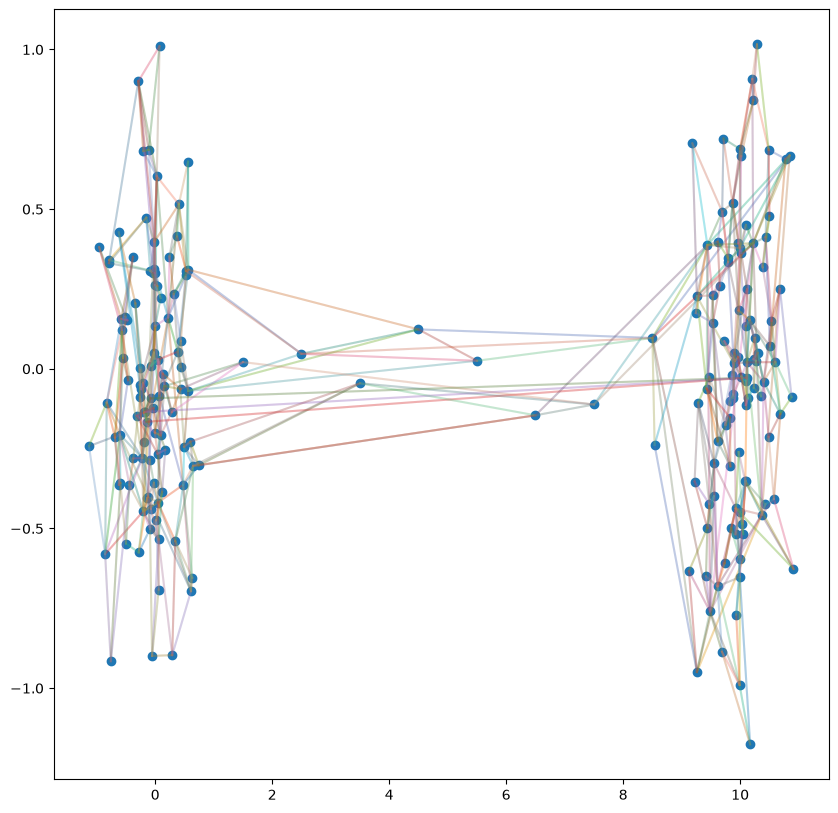

In [7]:
plot_graph(X, graph)

In [15]:

def ann_search_query(graph, X, q, k=1, m=3):
    """
    Multi-start NSW approximate nearest-neighbor search.

    graph: adjacency list {node_id: [neighbor_ids]}
    X: dataset (NumPy array)
    q: query vector
    k: number of nearest neighbors to return
    m: number of random starting points
    """
    if not graph:
        return []

    result = {}
    visitedSet = set()
    nodes = list(graph.keys())
    rng = np.random.default_rng()

    for _ in range(m):
        candidates = []
        tempRes = {}

        entry = rng.choice(nodes)
        d = distance_metric(X[entry], q)

        heapq.heappush(candidates, (d, entry))
        visitedSet.add(entry)
        tempRes[entry] = d

        while candidates:
            dist, c = heapq.heappop(candidates)

            # Stop if the next candidate is farther
            # than the worst currently retained result.
            if len(tempRes) >= k:
                worst_dist = max(tempRes.values())
                if dist > worst_dist:
                    break

            for n in graph[c]:
                if n in visitedSet:
                    continue

                visitedSet.add(n)
                d = distance_metric(X[n], q)

                # Consider the newly discovered node.
                if len(tempRes) < k or d < max(tempRes.values()):
                    tempRes[n] = d
                    heapq.heappush(candidates, (d, n))

                    # Retain only the k best results.
                    if len(tempRes) > k:
                        worst_node = max(tempRes, key=tempRes.get)
                        del tempRes[worst_node]

        # Merge results from this search into global results.
        result.update(tempRes)

    return sorted(result, key=result.get)[:k]


query = [4, -0.5]
ann = ann_search_query(graph, X, query)
ann = X[ann][0]
ann

array([ 3.5       , -0.04524893])

In [16]:
# lets find the actual nearest neighbour
def exact_search(X, query):
    distances = np.linalg.norm(X - query, axis=1)
    return np.argmin(distances)

enn = X[exact_search(X, query)]
enn

array([ 3.5       , -0.04524893])

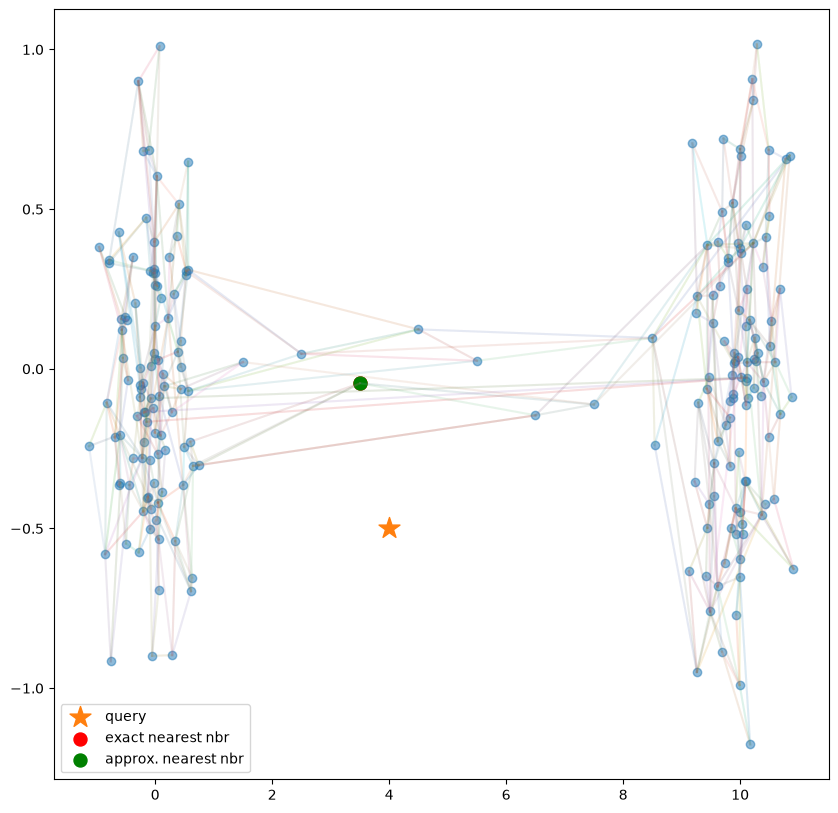

In [17]:
def plot_search(X, graph, query, exact_nn, ann):

    plt.figure(figsize=(10, 10))

    # Graph
    for i, neighbors in graph.items():
        for j in neighbors:
            plt.plot(
                [X[i, 0], X[j, 0]],
                [X[i, 1], X[j, 1]],
                alpha=0.08
            )

    # All points
    plt.scatter(
        X[:, 0],
        X[:, 1],
        alpha=0.5
    )

    # Query
    plt.scatter(
        query[0],
        query[1],
        marker="*",
        s=250, 
        label = 'query'
    )

    plt.scatter(
        exact_nn[0],
        exact_nn[1], 
        marker = '.', 
        s = 350, 
        c = 'r', 
        label='exact nearest nbr'
    )
        
    plt.scatter(
        ann[0],
        ann[1], 
        marker = '.', 
        s = 350, 
        c = 'g', 
        label='approx. nearest nbr'
    )
    
    plt.legend()    
    plt.show() 
    
    
plot_search(X, graph=graph, query=query, exact_nn=enn, ann=ann)

In [22]:
def recall_at_k(graph, X, n_queries=500, k=1, m=1, seed=0):
    rng = np.random.default_rng(seed)
    lo, hi = X.min(0), X.max(0)
    Q = rng.uniform(lo, hi, size=(n_queries, X.shape[1]))
    hits = 0
    for q in Q:
        exact = set(np.argsort(np.linalg.norm(X - q, axis=1))[:k])
        approx = set(ann_search_query(graph, X, q, k=k, m=m))
        hits += len(exact & approx) / k
    return hits / n_queries

for m in [1, 2, 3, 10]:
    print(m, recall_at_k(graph, X, k=1, m=m))

1 0.414
2 0.56
3 0.662
10 0.916
